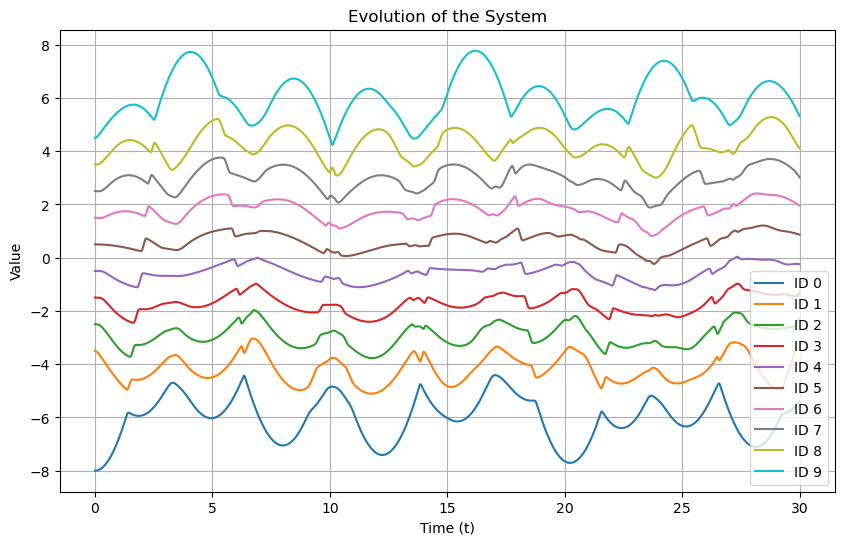

In [1]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib.animation import FuncAnimation
import os

data_list = []
current_time = None

with open('trayectoria1Dregen.dat', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
            
        # Check if the line defines the time step
        if line.startswith('t ='):
            current_time = float(line.split('=')[1])
        else:
            # Split the line by whitespace and grab the first two values
            parts = line.split()
            if len(parts) >= 2:
                data_list.append({
                    'time': current_time,
                    'id': int(parts[0]),
                    'value': float(parts[1])
                })

# Convert to a DataFrame for easy handling
df = pd.DataFrame(data_list)

plt.figure(figsize=(10, 6))
for sys_id in df['id'].unique():
    subset = df[df['id'] == sys_id]
    plt.plot(subset['time'], subset['value'], label=f'ID {sys_id}')

plt.xlabel('Time (t)')
plt.ylabel('Value')
plt.title('Evolution of the System')
plt.legend()
plt.grid(True)
plt.savefig(f"trayectoria.png", dpi=300, bbox_inches='tight')
plt.show()




#os.system("cd compound && convert -delay 10 -loop 0 *.png compound.gif && xdg-open compound.gif")

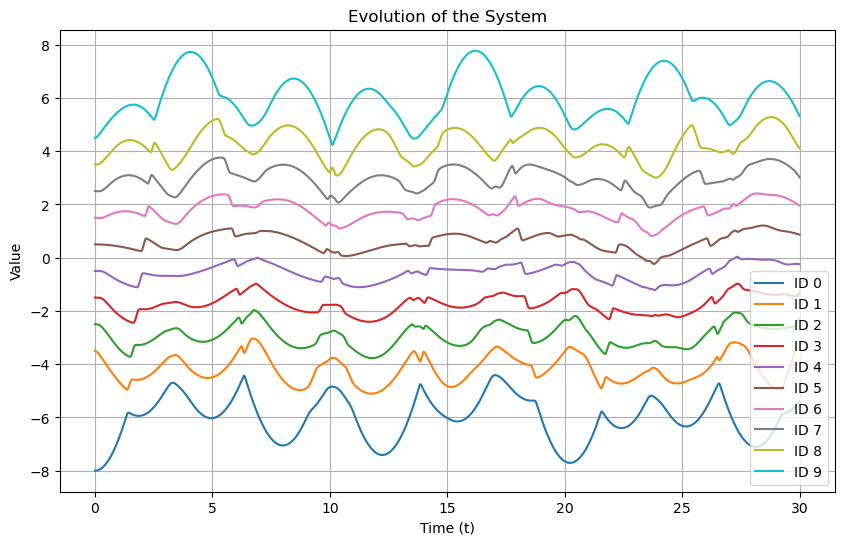

In [1]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib.animation import FuncAnimation
import os

data_list = []
current_time = None

with open('trayectoria1Dcorr.dat', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
            
        # Check if the line defines the time step
        if line.startswith('t ='):
            current_time = float(line.split('=')[1])
        else:
            # Split the line by whitespace and grab the first two values
            parts = line.split()
            if len(parts) >= 2:
                data_list.append({
                    'time': current_time,
                    'id': int(parts[0]),
                    'value': float(parts[1])
                })

# Convert to a DataFrame for easy handling
df = pd.DataFrame(data_list)

plt.figure(figsize=(10, 6))
for sys_id in df['id'].unique():
    subset = df[df['id'] == sys_id]
    plt.plot(subset['time'], subset['value'], label=f'ID {sys_id}')

plt.xlabel('Time (t)')
plt.ylabel('Value')
plt.title('Evolution of the System')
plt.legend()
plt.grid(True)
plt.savefig(f"trayectoria10.png", dpi=300, bbox_inches='tight')
plt.show()




#os.system("cd compound && convert -delay 10 -loop 0 *.png compound.gif && xdg-open compound.gif")

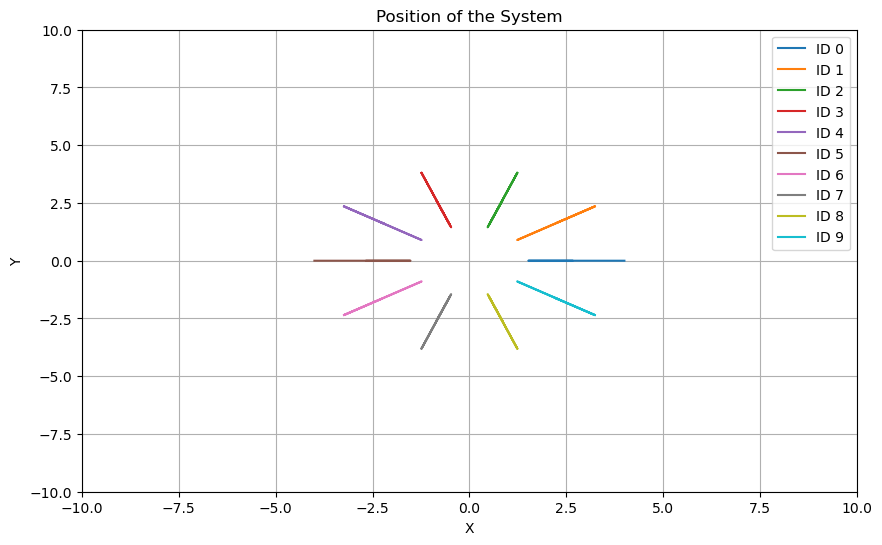

In [7]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib.animation import FuncAnimation
import os

data_list = []
current_time = None

with open('trayectoria2Dringregen.dat', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
            
        # Check if the line defines the time step
        if line.startswith('#t ='):
            current_time = float(line.split('=')[1])
        else:
            # Split the line by whitespace and grab the first two values
            parts = line.split()
            if len(parts) >= 2:
                data_list.append({
                    'time': current_time,
                    'id': int(parts[0]),
                    'x_value': float(parts[1]),
                    'y_value': float(parts[2])
                })

# Convert to a DataFrame for easy handling
df = pd.DataFrame(data_list)

plt.figure(figsize=(10, 6))
for sys_id in df['id'].unique():
    subset = df[df['id'] == sys_id]
    plt.plot(subset['x_value'], subset['y_value'], label=f'ID {sys_id}')

plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(-10,10)
plt.ylim(-10,10)
#plt.xlim(df['pos_x'].min() - 0.1, subset['pos_x'].max() + 0.1)
#plt.ylim(subset['pos_y'].min() - 0.1, subset['pos_y'].max() + 0.1)
plt.title('Position of the System')
plt.legend()
plt.grid(True)
plt.savefig(f"trayectoriaringregen.png", dpi=300, bbox_inches='tight')
plt.show()




#os.system("cd compound && convert -delay 10 -loop 0 *.png compound.gif && xdg-open compound.gif")

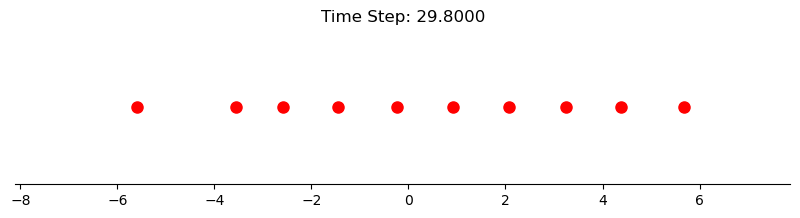

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- 1. Efficient Import with Subsampling ---
data_list = []
current_time = None
time_step_count = -1 
sample_rate = 200  # Adjust this: higher = faster/fewer frames, lower = smoother

with open('trayectoria1Dregen.dat', 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        
        if line.startswith('t ='):
            current_time = float(line.split('=')[1])
            time_step_count += 1
        
        # Only process every Nth time step
        if time_step_count % sample_rate == 0 and not line.startswith('t ='):
            parts = line.split()
            if len(parts) >= 2:
                data_list.append({
                    'time': current_time,
                    'pos_x': float(parts[1])  # Using the second column as X position
                })

df = pd.DataFrame(data_list)
unique_times = df['time'].unique()

# --- 2. Setup the 1D Plot ---
fig, ax = plt.subplots(figsize=(10, 2)) # Wide and short for 1D
#ax.set_ylim(-0.5, 0.5)
#ax.set_xlim(-100, 100)
ax.set_xlim(df['pos_x'].min() - 0.1, df['pos_x'].max() + 0.1)
ax.set_xlim(df['pos_x'].min() - 0.1, df['pos_x'].max() + 0.1)

# Hide the Y axis since it's 1D
ax.get_yaxis().set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# The particles (y is always 0)
particles, = ax.plot([], [], 'ro', ms=8)
title = ax.set_title('')

def update(t):
    current_positions = df[df['time'] == t]['pos_x']
    # Update x-data; y-data is just a list of zeros
    particles.set_data(current_positions, [0] * len(current_positions))
    title.set_text(f'Time Step: {t:.4f}')
    return particles, title

# --- 3. Create and Save ---
ani = FuncAnimation(fig, update, frames=unique_times, blit=True, interval=40)

# Requires 'pillow' library: pip install pillow
ani.save('1d_evolution_varied100.gif', writer='pillow', fps=25)
plt.show()

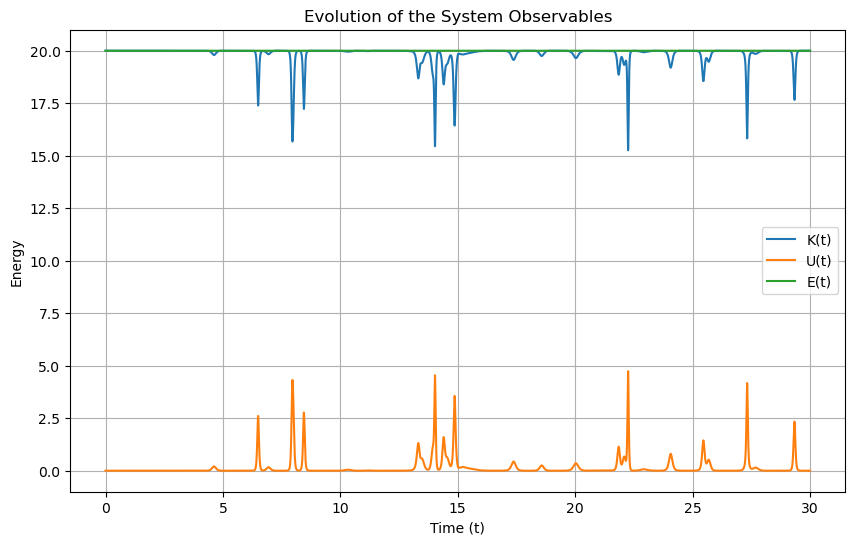

In [31]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib.animation import FuncAnimation
import os

t, K, U, E = np.loadtxt("observables2DPTchaos.dat", delimiter=" ", skiprows=1, unpack = True)

plt.figure(figsize=(10, 6))
plt.plot(t, K, label=f'K(t)')
plt.plot(t, U, label=f'U(t)')
plt.plot(t, E, label=f'E(t)')

plt.xlabel('Time (t)')
plt.ylabel('Energy')
plt.title('Evolution of the System Observables')
plt.legend()
plt.grid(True)
plt.savefig(f"observables2DPTchaos.png", dpi=300, bbox_inches='tight')
plt.show()




#os.system("cd compound && convert -delay 10 -loop 0 *.png compound.gif && xdg-open compound.gif")

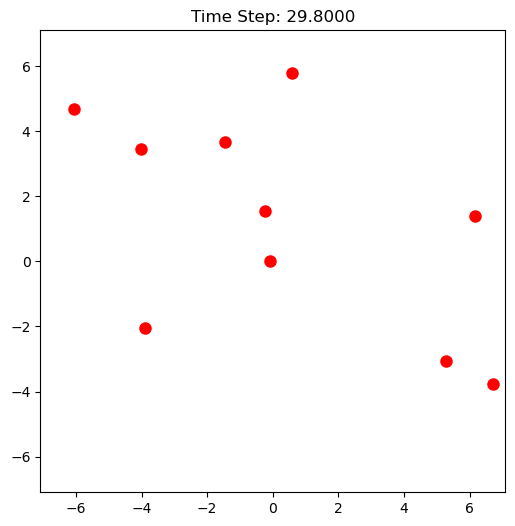

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# --- 1. Efficient Import with Subsampling ---
data_list = []
current_time = None
time_step_count = -1 
sample_rate = 200  # Adjust this: higher = faster/fewer frames, lower = smoother

with open('trayectoria2DPTchaos.dat', 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue

        
        if line.startswith('#t ='):
            current_time = float(line.split('=')[1])
            time_step_count += 1
        
        # Only process every Nth time step
        if time_step_count % sample_rate == 0 and not line.startswith('#t =') and not line.startswith('10'):
            parts = line.split()
            if len(parts) >= 2:
                data_list.append({
                    'time': current_time,
                    'pos_x': float(parts[1]),  # Using the second column as X position
                    'pos_y': float(parts[2])  # Using the third column as Y position
                })

df = pd.DataFrame(data_list)
unique_times = df['time'].unique()

# --- 2. Setup the 1D Plot ---
fig, ax = plt.subplots(figsize=(6, 6)) # Wide and short for 2D
#ax.set_ylim(-1000, 1000)
#ax.set_xlim(-1000, 1000)
ax.set_xlim(df['pos_x'].min() - 0.1, df['pos_x'].max() + 0.1)
ax.set_ylim(df['pos_y'].min() - 0.1, df['pos_y'].max() + 0.1)

# Hide the Y axis since it's 1D
#ax.get_yaxis().set_visible(False)
#ax.spines['left'].set_visible(False)
#ax.spines['right'].set_visible(False)
#ax.spines['top'].set_visible(False)

# The particles (y is always 0)
particles, = ax.plot([], [], 'ro', ms=8)
title = ax.set_title('')

def update(t):
    current_xpositions = df[df['time'] == t]['pos_x']
    current_ypositions = df[df['time'] == t]['pos_y']
    # Update x-data; y-data is just a list of zeros
    particles.set_data(current_xpositions, current_ypositions)
    title.set_text(f'Time Step: {t:.4f}')
    return particles, title

# --- 3. Create and Save ---
ani = FuncAnimation(fig, update, frames=unique_times, blit=True, interval=40)

# Requires 'pillow' library: pip install pillow
ani.save('2d_evolution_PTchaos.gif', writer='pillow', fps=25)
plt.show()